In [3]:
from torchvision import datasets

dataset = datasets.ImageFolder(
    "../data/raw/chest"
)

print(dataset.classes)
print(len(dataset))

['Normal', 'Tuberculosis']
4200


In [16]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from torchvision import datasets, transforms, models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

In [4]:
from PIL import Image

image = Image.open("../data/raw/chest/Normal/Normal-1.png")

print(image.size)
print(image.mode)

(512, 512)
RGB


In [9]:
import cv2

image = cv2.imread(
    "../data/raw/chest/Normal/Normal-1.png",
    cv2.IMREAD_GRAYSCALE
)

image = cv2.resize(image, (512, 512))

In [10]:
from pathlib import Path
from collections import Counter

data_path = Path("../data/raw/chest")

images = list(data_path.rglob("*.png")) + \
         list(data_path.rglob("*.jpg")) + \
         list(data_path.rglob("*.jpeg"))

print("Total images:", len(images))

classes = Counter(image.parent.name for image in images)

print("\nClasses:")
for cls, count in classes.items():
    print(f"{cls}: {count}")

Total images: 4200

Classes:
Normal: 3500
Tuberculosis: 700


In [11]:
from PIL import Image

sizes = []

for path in images[:100]:
    try:
        img = Image.open(path)
        sizes.append(img.size)
    except Exception as e:
        print("Bad image:", path, e)

print("Example sizes:", sizes[:10])

Example sizes: [(512, 512), (512, 512), (512, 512), (512, 512), (512, 512), (512, 512), (512, 512), (512, 512), (512, 512), (512, 512)]


In [12]:
modes = Counter()

for path in images[:100]:
    try:
        img = Image.open(path)
        modes[img.mode] += 1
    except:
        pass

print(modes)

Counter({'RGB': 100})


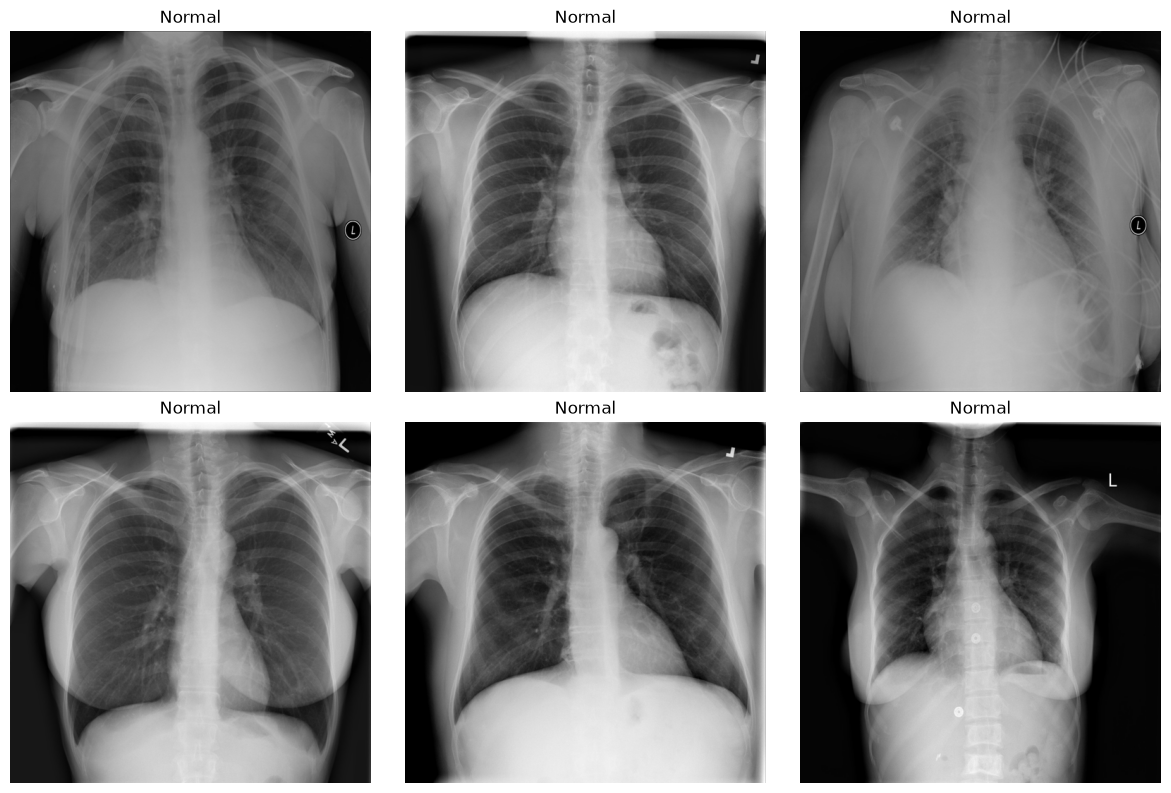

In [13]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, path in zip(axes.ravel(), images[:6]):
    img = Image.open(path)

    ax.imshow(img, cmap="gray")
    ax.set_title(path.parent.name)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [14]:
cv2.imread("../data/raw/chest/Normal/Normal-1.png")

array([[[ 2,  2,  2],
        [ 3,  3,  3],
        [ 3,  3,  3],
        ...,
        [18, 18, 18],
        [13, 13, 13],
        [ 6,  6,  6]],

       [[ 3,  3,  3],
        [ 4,  4,  4],
        [ 4,  4,  4],
        ...,
        [18, 18, 18],
        [17, 17, 17],
        [ 9,  9,  9]],

       [[ 2,  2,  2],
        [ 3,  3,  3],
        [ 3,  3,  3],
        ...,
        [ 5,  5,  5],
        [ 5,  5,  5],
        [ 3,  3,  3]],

       ...,

       [[ 3,  3,  3],
        [ 4,  4,  4],
        [ 4,  4,  4],
        ...,
        [ 9,  9,  9],
        [ 8,  8,  8],
        [ 7,  7,  7]],

       [[ 3,  3,  3],
        [ 4,  4,  4],
        [ 4,  4,  4],
        ...,
        [ 9,  9,  9],
        [ 8,  8,  8],
        [ 7,  7,  7]],

       [[ 1,  1,  1],
        [ 2,  2,  2],
        [ 2,  2,  2],
        ...,
        [ 6,  6,  6],
        [ 5,  5,  5],
        [ 4,  4,  4]]], shape=(512, 512, 3), dtype=uint8)

In [17]:
IMAGE_SIZE = 224

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [19]:
from pathlib import Path

DATA_DIR = Path("../data/raw/chest")

print(DATA_DIR.resolve())
print(DATA_DIR.exists())

C:\Users\Stro_on\Documents\Projects\Medical-imaging-MLOps\data\raw\Chest
True


In [20]:
classes = [
    folder.name
    for folder in DATA_DIR.iterdir()
    if folder.is_dir()
]

print(classes)

['Normal', 'Tuberculosis']


In [21]:
from sklearn.model_selection import train_test_split
import shutil
from pathlib import Path

OUTPUT_DIR = Path("../data/processed/chest")

# Create directories
for split in ["train", "val", "test"]:
    for class_name in classes:
        (OUTPUT_DIR / split / class_name).mkdir(
            parents=True,
            exist_ok=True
        )

# Collect images
image_extensions = {".png", ".jpg", ".jpeg"}

records = []

for class_name in classes:
    class_dir = DATA_DIR / class_name

    for image_path in class_dir.iterdir():
        if image_path.suffix.lower() in image_extensions:
            records.append({
                "path": image_path,
                "label": class_name
            })

print("Total images:", len(records))

Total images: 4200


In [22]:
import pandas as pd

df = pd.DataFrame(records)

print(df["label"].value_counts())

label
Normal          3500
Tuberculosis     700
Name: count, dtype: int64


In [24]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 2940
Validation: 630
Test: 630


In [25]:
def copy_images(dataframe, split):

    for _, row in dataframe.iterrows():

        destination = (
            OUTPUT_DIR
            / split
            / row["label"]
            / row["path"].name
        )

        shutil.copy2(
            row["path"],
            destination
        )


copy_images(train_df, "train")
copy_images(val_df, "val")
copy_images(test_df, "test")

In [26]:
for split in ["train", "val", "test"]:

    count = sum(
        len(list((OUTPUT_DIR / split / c).glob("*")))
        for c in classes
    )

    print(split, count)

train 2940
val 630
test 630


In [27]:
train_dir = "../data/processed/chest/train"
val_dir = "../data/processed/chest/val"
test_dir = "../data/processed/chest/test"

In [28]:
from torchvision import datasets

train_dataset = datasets.ImageFolder(
    train_dir,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    val_dir,
    transform=val_transform
)

test_dataset = datasets.ImageFolder(
    test_dir,
    transform=val_transform
)

In [29]:
print("Classes:", train_dataset.classes)
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Classes: ['Normal', 'Tuberculosis']
Train: 2940
Validation: 630
Test: 630


In [30]:
from pathlib import Path

DATA_DIR = Path("../data/raw/chest")

for folder in DATA_DIR.iterdir():
    if folder.is_dir():
        print(folder.name, "→", len(list(folder.iterdir())))

Normal → 3500
Tuberculosis → 700


In [32]:
from torchvision import transforms

IMAGE_SIZE = 224

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [33]:
from torchvision import datasets

train_dataset = datasets.ImageFolder(
    train_dir,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    val_dir,
    transform=val_transform
)

test_dataset = datasets.ImageFolder(
    test_dir,
    transform=val_transform
)

print("Classes:", train_dataset.classes)
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Classes: ['Normal', 'Tuberculosis']
Train: 2940
Validation: 630
Test: 630


In [34]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

In [35]:
images, labels = next(iter(train_loader))

print("Images:", images.shape)
print("Labels:", labels.shape)
print("Labels:", labels[:10])

Images: torch.Size([32, 3, 224, 224])
Labels: torch.Size([32])
Labels: tensor([0, 0, 1, 0, 0, 0, 0, 0, 0, 0])


In [36]:
import torch
import torch.nn as nn

class_counts = torch.tensor([
    2450,   # Normal
    490     # Tuberculosis
], dtype=torch.float)

class_weights = class_counts.sum() / (
    len(class_counts) * class_counts
)

print(class_weights)

tensor([0.6000, 3.0000])


In [38]:
import torch

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

Device: cpu


In [39]:
from collections import Counter

counts = Counter(
    train_dataset.targets
)

class_counts = torch.tensor(
    [
        counts[i]
        for i in range(len(train_dataset.classes))
    ],
    dtype=torch.float
)

class_weights = class_counts.sum() / (
    len(class_counts) * class_counts
)

class_weights = class_weights.to(DEVICE)

print("Class counts:", class_counts)
print("Class weights:", class_weights)

Class counts: tensor([2450.,  490.])
Class weights: tensor([0.6000, 3.0000])


In [41]:
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.13.0+cpu
CUDA available: False


In [43]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

In [44]:
BATCH_SIZE = 16
EPOCHS = 5

In [45]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm
import time

In [46]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cpu


In [47]:
BATCH_SIZE = 16          # safer for CPU
EPOCHS = 5               # start small, confirm pipeline works
LEARNING_RATE = 1e-4


In [48]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(train_dataset.classes))
model = model.to(DEVICE)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Stro_on/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:04<00:00, 10.9MB/s]


In [50]:
criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))

optimizer = Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

In [52]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc="Train", leave=False)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        pbar.set_postfix(loss=loss.item())

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [53]:
def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        pbar = tqdm(loader, desc="Val  ", leave=False)
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [55]:
history = {
    "train_loss": [], "train_acc": [],
    "val_loss": [], "val_acc": []
}

best_val_acc = 0.0
best_model_path = "best_resnet18.pth"

print(f"\nStarting training for {EPOCHS} epochs on {DEVICE}...\n")
start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    print(f"Epoch {epoch}/{EPOCHS}")
    
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE
    )
    
    val_loss, val_acc = validate(
        model, val_loader, criterion, DEVICE
    )
    
    scheduler.step(val_loss)
    
    # Save history
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"  → Best model saved (val_acc: {best_val_acc:.4f})")
    
    print("-" * 50)


Starting training for 5 epochs on cpu...

Epoch 1/5


  Train Loss: 0.0761 | Train Acc: 0.9741
  Val   Loss: 0.0416 | Val   Acc: 0.9857
  → Best model saved (val_acc: 0.9857)
--------------------------------------------------
Epoch 2/5


  Train Loss: 0.0246 | Train Acc: 0.9925
  Val   Loss: 0.0159 | Val   Acc: 0.9952
  → Best model saved (val_acc: 0.9952)
--------------------------------------------------
Epoch 3/5


  Train Loss: 0.0137 | Train Acc: 0.9969
  Val   Loss: 0.0028 | Val   Acc: 1.0000
  → Best model saved (val_acc: 1.0000)
--------------------------------------------------
Epoch 4/5


  Train Loss: 0.0132 | Train Acc: 0.9966
  Val   Loss: 0.0263 | Val   Acc: 0.9921
--------------------------------------------------
Epoch 5/5


  Train Loss: 0.0186 | Train Acc: 0.9932
  Val   Loss: 0.0020 | Val   Acc: 1.0000
--------------------------------------------------


In [56]:
total_time = time.time() - start_time
print(f"\nTraining finished in {total_time/60:.1f} minutes")
print(f"Best validation accuracy: {best_val_acc:.4f}")
print(f"Best model saved to: {best_model_path}")


Training finished in 22.0 minutes
Best validation accuracy: 1.0000
Best model saved to: best_resnet18.pth


In [57]:
 print(len(train_dataset), len(val_dataset))

2940 630


In [59]:
print(len(train_dataset.classes))
print(train_dataset.classes)

2
['Normal', 'Tuberculosis']


In [60]:
print("Train Acc:", [round(x, 4) for x in history["train_acc"]])
print("Val   Acc:", [round(x, 4) for x in history["val_acc"]])
print("Train Loss:", [round(x, 4) for x in history["train_loss"]])
print("Val   Loss:", [round(x, 4) for x in history["val_loss"]])

Train Acc: [0.9741, 0.9925, 0.9969, 0.9966, 0.9932]
Val   Acc: [0.9857, 0.9952, 1.0, 0.9921, 1.0]
Train Loss: [0.0761, 0.0246, 0.0137, 0.0132, 0.0186]
Val   Loss: [0.0416, 0.0159, 0.0028, 0.0263, 0.002]


In [61]:
print("Train size:", len(train_dataset))
print("Val size  :", len(val_dataset))
print("Classes   :", train_dataset.classes)
print("Num classes:", len(train_dataset.classes))

Train size: 2940
Val size  : 630
Classes   : ['Normal', 'Tuberculosis']
Num classes: 2


In [62]:
train_paths = set([s[0] for s in train_dataset.samples])
val_paths   = set([s[0] for s in val_dataset.samples])

overlap = train_paths.intersection(val_paths)
print("Overlapping images:", len(overlap))

Overlapping images: 0


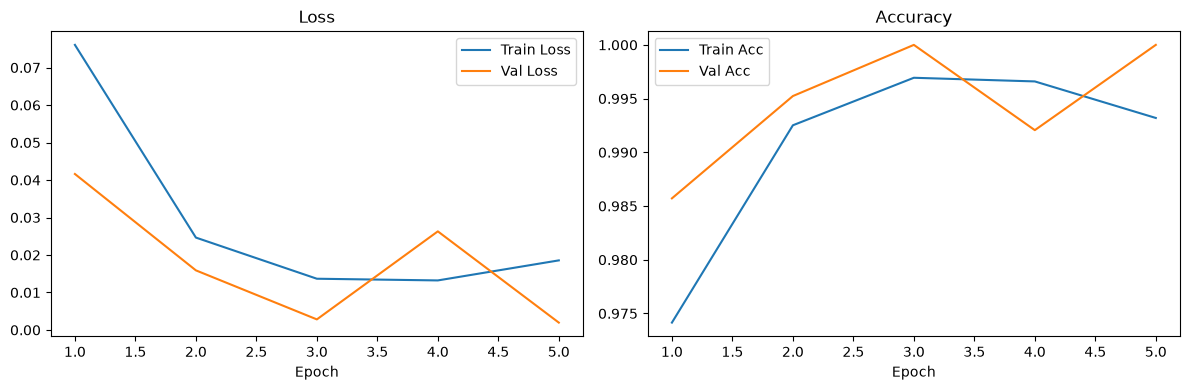

Testing: 100%|██████████| 20/20 [00:27<00:00,  1.36s/it]



Classification Report (Test Set):
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       525
Tuberculosis       0.99      0.98      0.99       105

    accuracy                           1.00       630
   macro avg       0.99      0.99      0.99       630
weighted avg       1.00      1.00      1.00       630



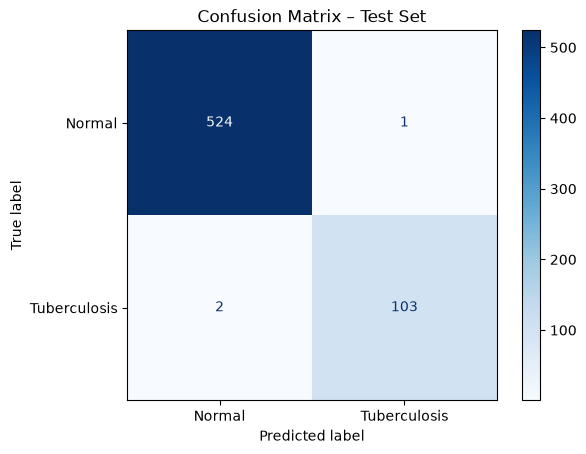

In [63]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# -------------------------------------------------
# 1. Plot history
# -------------------------------------------------
epochs_range = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Val Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["train_acc"], label="Train Acc")
plt.plot(epochs_range, history["val_acc"], label="Val Acc")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.legend()

plt.tight_layout()
plt.show()

# -------------------------------------------------
# 2. Load best model & evaluate on TEST set
# -------------------------------------------------
model.load_state_dict(torch.load("best_resnet18.pth"))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images = images.to(DEVICE)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# -------------------------------------------------
# 3. Classification report + Confusion matrix
# -------------------------------------------------
print("\nClassification Report (Test Set):")
print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_dataset.classes)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix – Test Set")
plt.show()

In [64]:
train_paths = set([s[0] for s in train_dataset.samples])
val_paths   = set([s[0] for s in val_dataset.samples])
print("Overlapping images:", len(train_paths.intersection(val_paths)))

Overlapping images: 0


In [65]:
print(classification_report(all_labels, all_preds, target_names=train_dataset.classes, digits=4))

              precision    recall  f1-score   support

      Normal     0.9962    0.9981    0.9971       525
Tuberculosis     0.9904    0.9810    0.9856       105

    accuracy                         0.9952       630
   macro avg     0.9933    0.9895    0.9914       630
weighted avg     0.9952    0.9952    0.9952       630



In [66]:
torch.save({
    'model_state_dict': model.state_dict(),
    'class_names': train_dataset.classes,
    'best_val_acc': best_val_acc,
}, "final_resnet18_tb.pth")
print("Final model saved!")

Final model saved!
